# 任务4：四组空间特征模型对比

使用完全相同的 240 组随机划分、728/128 训练测试数量和 XGBoost 参数，对比：

1. 原始6特征
2. 原始6特征 + rg
3. 原始6特征 + rg + asphericity
4. 原始6特征 + rg + asphericity + rg_mw_ratio


In [1]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

DATA_FILE = Path('model_input_6_plus_spatial_856.csv')
RESULT_DIR = Path('task4_four_model_results')
RESULT_DIR.mkdir(exist_ok=True)

N_RUNS = 240
SEEDS = list(range(N_RUNS))
TRAIN_SIZE = 728
TEST_SIZE = 128
LN10 = np.log(10)


In [2]:
if not DATA_FILE.exists():
    raise FileNotFoundError(
        f'找不到数据文件：{DATA_FILE.resolve()}\n'
        '请把 model_input_6_plus_spatial_856.csv 与本 Notebook 放在同一文件夹。'
    )

df = pd.read_csv(DATA_FILE)
print('数据形状：', df.shape)
print('缺失值总数：', int(df.isna().sum().sum()))
display(df.head())


数据形状： (856, 21)
缺失值总数： 0


,model_row,Old_index_1,smiles,canonical_smiles,doi,compoundId,Conju-Max-Distance,Wavelength (Exp nm),ET(30) (Solvent),PEOE-Charge-Max,...,Atomic-MR-Max,rg,asphericity,eccentricity,num_chiral_centers,num_cis_trans,rg_mw_ratio,molecular_weight,rigid_bond_ratio,values_ln
0,0,1,CCN(CC)c1ccc2c(c1)O[B-](c1ccccc1)(c1ccccc1)[N+...,CAN:CCN(CC)c1ccc2c(c1)O[B-](c1ccccc1)(c1ccccc1...,10.1016/j.jorganchem.2013.12.036,2a,10,750,37.4,0.285785,...,26.486,4.209492,0.242658,0.915303,0,0,0.009736,432.376,0.135135,3.871201
1,1,2,CCN(CC)c1ccc2c(c1)O[B-](c1ccccc1)(c1ccccc1)[N+...,CAN:CCN(CC)c1ccc2c(c1)O[B-](c1ccccc1)(c1ccccc1...,10.1016/j.jorganchem.2013.12.036,2b,11,760,37.4,0.285785,...,26.486,4.353599,0.268298,0.926502,0,0,0.009667,450.366,0.131579,3.828641
2,2,3,CCN(CC)c1ccc2c(c1)O[B-](c1ccccc1)(c1ccccc1)[N+...,CAN:CCN(CC)c1ccc2c(c1)O[B-](c1ccccc1)(c1ccccc1...,10.1016/j.jorganchem.2013.12.037,2c,11,750,37.4,0.285785,...,26.486,4.533366,0.269609,0.927593,0,0,0.009711,466.821,0.131579,4.477337
3,3,5,CCN(CC)c1ccc2c(c1)O[B-](c1ccccc1)(c1ccccc1)[N+...,CAN:CCN(CC)c1ccc2c(c1)O[B-](c1ccccc1)(c1ccccc1...,10.1016/j.jorganchem.2013.12.039,2e,11,750,37.4,0.285785,...,26.486,4.512181,0.271346,0.927907,0,0,0.009758,462.402,0.128205,3.713572
4,4,6,CCN(CC)c1ccc([N+]2=Cc3ccc(N(CC)CC)cc3O[B-]2(c2...,CAN:CCN(CC)c1ccc([N+]2=Cc3ccc(N(CC)CC)cc3O[B-]...,10.1016/j.jorganchem.2013.12.040,2f,11,740,37.4,0.285785,...,26.486,4.850971,0.365411,0.955132,0,0,0.009635,503.499,0.119048,3.988984


In [3]:
BASE_FEATURES = [
    'Conju-Max-Distance',
    'Wavelength (Exp nm)',
    'ET(30) (Solvent)',
    'PEOE-Charge-Max',
    'Atomic-LogP-Min',
    'Atomic-MR-Max',
]

MODEL_FEATURES = {
    'M0_原始6特征': BASE_FEATURES,
    'M1_原始6特征+rg': BASE_FEATURES + ['rg'],
    'M2_原始6特征+rg+asphericity': BASE_FEATURES + ['rg', 'asphericity'],
    'M3_原始6特征+rg+asphericity+rg_mw_ratio': (
        BASE_FEATURES + ['rg', 'asphericity', 'rg_mw_ratio']
    ),
}

TARGET = 'values_ln'

required = sorted(set(sum(MODEL_FEATURES.values(), [])) | {TARGET})
missing = [c for c in required if c not in df.columns]
if missing:
    raise KeyError(f'数据文件缺少这些列：{missing}')

for name, features in MODEL_FEATURES.items():
    print(f'{name}: {len(features)} 个特征')


M0_原始6特征: 6 个特征
M1_原始6特征+rg: 7 个特征
M2_原始6特征+rg+asphericity: 8 个特征
M3_原始6特征+rg+asphericity+rg_mw_ratio: 9 个特征


In [4]:
XGB_PARAMS = dict(
    n_estimators=150,
    learning_rate=0.025,
    max_depth=13,
    verbosity=0,
    booster='gbtree',
    reg_alpha=np.exp(-6.788644799030888),
    reg_lambda=np.exp(-7.450413274554533),
    gamma=np.exp(-5.374463422208394),
    subsample=0.5,
    objective='reg:squarederror',
    n_jobs=-1,
)

def evaluate_model(model_name, feature_names):
    X = df[feature_names].astype(float)
    y = df[TARGET].astype(float)
    indices = np.arange(len(df))
    rows = []

    for seed in SEEDS:
        train_idx, test_idx = train_test_split(
            indices,
            train_size=TRAIN_SIZE,
            test_size=TEST_SIZE,
            random_state=seed,
            shuffle=True,
        )

        model = XGBRegressor(random_state=seed, **XGB_PARAMS)
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        pred = model.predict(X.iloc[test_idx])

        mse_ln = mean_squared_error(y.iloc[test_idx], pred)
        mae_ln = mean_absolute_error(y.iloc[test_idx], pred)
        r2 = r2_score(y.iloc[test_idx], pred)

        rows.append({
            'model': model_name,
            'seed': seed,
            'n_features': len(feature_names),
            'MSE_ln': mse_ln,
            'MAE_ln': mae_ln,
            'MSE_lg': mse_ln / LN10**2,
            'MAE_lg': mae_ln / LN10,
            'R2': r2,
        })

    return pd.DataFrame(rows)


In [5]:
all_results = []

for model_name, feature_names in MODEL_FEATURES.items():
    print(f'正在训练：{model_name}')
    result = evaluate_model(model_name, feature_names)
    all_results.append(result)

metrics_df = pd.concat(all_results, ignore_index=True)
metrics_df.to_csv(
    RESULT_DIR / 'four_models_240_runs_metrics.csv',
    index=False,
    encoding='utf-8-sig',
)
print('全部模型训练完成。')


正在训练：M0_原始6特征
正在训练：M1_原始6特征+rg
正在训练：M2_原始6特征+rg+asphericity
正在训练：M3_原始6特征+rg+asphericity+rg_mw_ratio
全部模型训练完成。


In [6]:
summary = (
    metrics_df.groupby('model')[['MSE_lg', 'MAE_lg', 'R2']]
    .agg(['mean', 'std'])
)
display(summary.round(4))
summary.to_csv(
    RESULT_DIR / 'four_models_summary.csv',
    encoding='utf-8-sig',
)


MSE_lg          MAE_lg              R2  \
                                       mean     std    mean     std    mean   
model                                                                         
M0_原始6特征                             0.2148  0.0325  0.3464  0.0250  0.5868   
M1_原始6特征+rg                          0.2264  0.0339  0.3583  0.0258  0.5647   
M2_原始6特征+rg+asphericity              0.2333  0.0332  0.3665  0.0249  0.5515   
M3_原始6特征+rg+asphericity+rg_mw_ratio  0.2335  0.0331  0.3654  0.0246  0.5513   

                                             
                                        std  
model                                        
M0_原始6特征                             0.0629  
M1_原始6特征+rg                          0.0647  
M2_原始6特征+rg+asphericity              0.0627  
M3_原始6特征+rg+asphericity+rg_mw_ratio  0.0601

In [7]:
baseline = metrics_df[metrics_df['model'] == 'M0_原始6特征'].set_index('seed')
comparison_rows = []

for model_name in MODEL_FEATURES:
    current = metrics_df[metrics_df['model'] == model_name].set_index('seed')
    comparison_rows.append({
        'model': model_name,
        'MSE_lg_mean': current['MSE_lg'].mean(),
        'MAE_lg_mean': current['MAE_lg'].mean(),
        'R2_mean': current['R2'].mean(),
        'ΔMSE_vs_baseline': (current['MSE_lg'] - baseline['MSE_lg']).mean(),
        'ΔMAE_vs_baseline': (current['MAE_lg'] - baseline['MAE_lg']).mean(),
        'ΔR2_vs_baseline': (current['R2'] - baseline['R2']).mean(),
        'R2优于基准的次数': int((current['R2'] > baseline['R2']).sum()),
    })

comparison = pd.DataFrame(comparison_rows)
display(comparison.round(4))
comparison.to_csv(
    RESULT_DIR / 'comparison_vs_baseline.csv',
    index=False,
    encoding='utf-8-sig',
)


,model,MSE_lg_mean,MAE_lg_mean,R2_mean,ΔMSE_vs_baseline,ΔMAE_vs_baseline,ΔR2_vs_baseline,R2优于基准的次数
0,M0_原始6特征,0.2148,0.3464,0.5868,0.0000,0.0000,0.0000,0
1,M1_原始6特征+rg,0.2264,0.3583,0.5647,0.0116,0.0119,-0.0221,47
2,M2_原始6特征+rg+asphericity,0.2333,0.3665,0.5515,0.0185,0.0201,-0.0353,25
3,M3_原始6特征+rg+asphericity+rg_mw_ratio,0.2335,0.3654,0.5513,0.0187,0.0189,-0.0355,31


C:\Users\6\AppData\Local\Temp\ipykernel_5892\2670611420.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=['6特征', '+rg', '+rg+非球形度', '+rg+非球形度+rg/mw'])
C:\Users\6\AppData\Local\Temp\ipykernel_5892\2670611420.py:12: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\6\AppData\Local\Temp\ipykernel_5892\2670611420.py:12: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\6\AppData\Local\Temp\ipykernel_5892\2670611420.py:12: UserWarning: Glyph 38750 (\N{CJK UNIFIED IDEOGRAPH-975E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\6\AppData\Local\Temp\ipykernel_5892\2670611420.py:12: UserWarning: Glyph 29699 (\N{CJK UNIFIED IDEOGRAPH-7403}) missing from font(s) DejaVu Sans.
  plt.ti

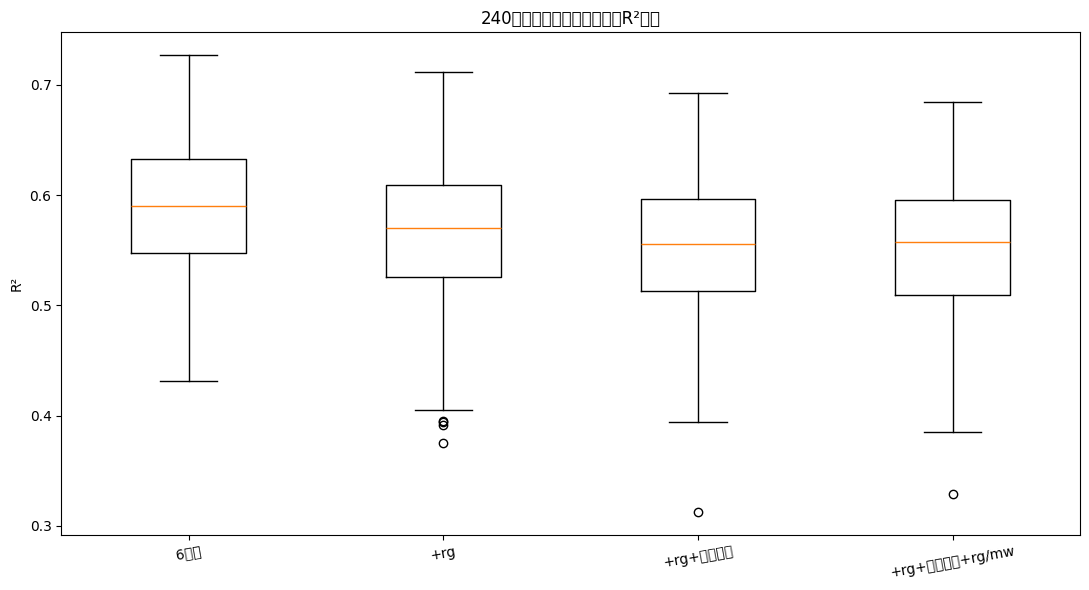

In [8]:
model_order = list(MODEL_FEATURES.keys())
plot_data = [
    metrics_df.loc[metrics_df['model'] == name, 'R2']
    for name in model_order
]

plt.figure(figsize=(11, 6))
plt.boxplot(plot_data, labels=['6特征', '+rg', '+rg+非球形度', '+rg+非球形度+rg/mw'])
plt.ylabel('R²')
plt.title('240次随机划分下四个模型的R²分布')
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig(RESULT_DIR / 'four_models_R2_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()


C:\Users\6\AppData\Local\Temp\ipykernel_5892\1130485792.py:12: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\6\AppData\Local\Temp\ipykernel_5892\1130485792.py:12: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\6\AppData\Local\Temp\ipykernel_5892\1130485792.py:12: UserWarning: Glyph 38750 (\N{CJK UNIFIED IDEOGRAPH-975E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\6\AppData\Local\Temp\ipykernel_5892\1130485792.py:12: UserWarning: Glyph 29699 (\N{CJK UNIFIED IDEOGRAPH-7403}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\6\AppData\Local\Temp\ipykernel_5892\1130485792.py:12: UserWarning: Glyph 24418 (\N{CJK UNIFIED IDEOGRAPH-5F62}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\6\AppData\Local\Temp\ipykernel_5892\1130485792.py:12: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6})

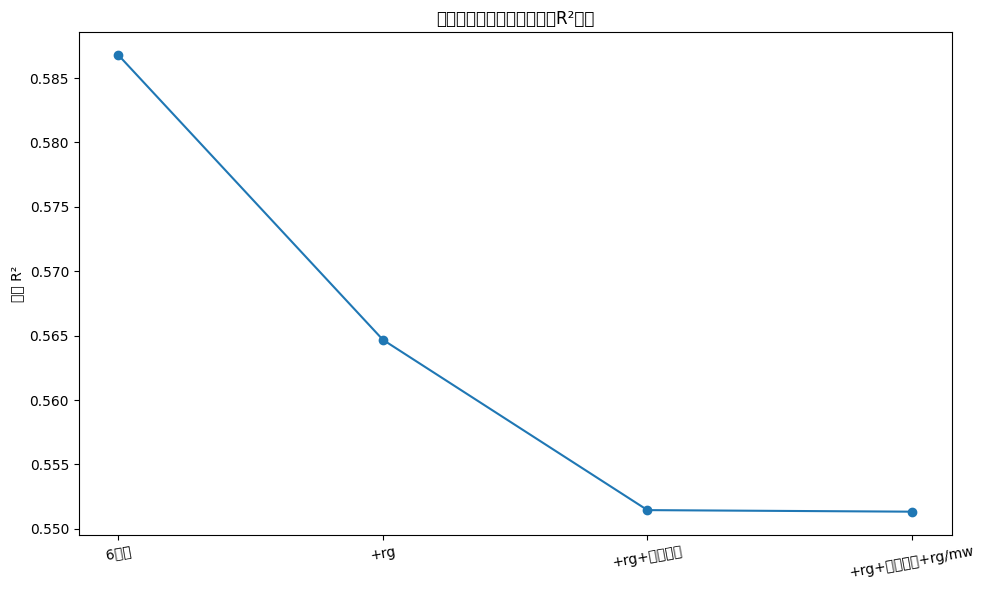

In [9]:
mean_table = metrics_df.groupby('model')[['MSE_lg', 'MAE_lg', 'R2']].mean().loc[model_order]

plt.figure(figsize=(10, 6))
plt.plot(range(len(model_order)), mean_table['R2'], marker='o')
plt.xticks(
    range(len(model_order)),
    ['6特征', '+rg', '+rg+非球形度', '+rg+非球形度+rg/mw'],
    rotation=10,
)
plt.ylabel('平均 R²')
plt.title('空间特征逐步加入后的平均R²变化')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'mean_R2_trend.png', dpi=300, bbox_inches='tight')
plt.show()


In [10]:
best_model_name = (
    metrics_df.groupby('model')['R2'].mean().idxmax()
)
best_features = MODEL_FEATURES[best_model_name]

final_model = XGBRegressor(random_state=0, **XGB_PARAMS)
final_model.fit(df[best_features], df[TARGET])
joblib.dump(
    final_model,
    RESULT_DIR / 'best_four_model_full_data.joblib',
)

with open(RESULT_DIR / 'run_config.json', 'w', encoding='utf-8') as f:
    json.dump({
        'data_file': str(DATA_FILE),
        'n_samples': len(df),
        'train_size': TRAIN_SIZE,
        'test_size': TEST_SIZE,
        'n_runs': N_RUNS,
        'models': MODEL_FEATURES,
        'best_model_by_mean_R2': best_model_name,
        'xgb_params': XGB_PARAMS,
    }, f, ensure_ascii=False, indent=2)

print('平均R²最高的模型：', best_model_name)
print('对应特征：', best_features)
print('结果文件夹：', RESULT_DIR.resolve())


平均R²最高的模型： M0_原始6特征
对应特征： ['Conju-Max-Distance', 'Wavelength (Exp nm)', 'ET(30) (Solvent)', 'PEOE-Charge-Max', 'Atomic-LogP-Min', 'Atomic-MR-Max']
结果文件夹： C:\Users\6\Desktop\SJTU\MI Chemistry\4\tpaml_unified_output\task4_four_model_results
